# KNN Similarity Search & Market Basket Analysis
## Búsqueda de Similitud por KNN y Análisis de Canasta de Compras

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Datasets:**
- **Problem 1 / Problema 1:** Wine dataset — 178 wines × 13 chemical features (`wine-clustering.csv`)
- **Problem 2 / Problema 2:** Synthetic grocery basket — 11 transactions × 15 products (defined inline)

**Objective / Objetivo:**  
EN ·   
**Problem 1:** Use K-Nearest Neighbors (unsupervised) to find the 5 most chemically similar wines to a custom query wine, based on Euclidean distance in standardized feature space.  
**Problem 2:** Apply the Apriori algorithm to discover frequent itemsets and generate association rules (support, confidence, lift) from grocery transaction data.

ES ·   
**Problema 1:** Usar K-Nearest Neighbors (no supervisado) para encontrar los 5 vinos más similares a un vino de consulta, basado en distancia euclidiana en espacio estandarizado.  
**Problema 2:** Aplicar el algoritmo Apriori para descubrir itemsets frecuentes y generar reglas de asociación (soporte, confianza, lift) a partir de datos de transacciones de supermercado.

**Techniques / Técnicas:** KNN · NearestNeighbors · Market Basket · Apriori · Association Rules · Support · Confidence · Lift  
**Libraries / Librerías:** `pandas` · `numpy` · `sklearn` · `mlxtend` · `matplotlib`

> **Note / Nota:** `wine-clustering.csv` must be placed in the same directory as this notebook.  
> Download from: https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering

---

# PROBLEMA 1: K Vecinos Más Cercanos (KNN) — Wine Clustering

In [7]:
# ============================================================
# PROBLEMA 1: KNN - Wine Clustering
# ============================================================

# --- 1. Importación de librerías ---
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# --- 2. Carga del dataset ---
df = pd.read_csv('wine-clustering.csv')

# --- 3. Revisar en dataset ---
print(df.info())
print("\nPrimeras filas:")
print(df.head())
print("\nEstadísticas descriptivas:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB
None

Primeras filas:
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  T

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [8]:
# --- 4. Definir el vino de consulta (query point) ---
# Características del vino a consultar:
vino_consulta = pd.DataFrame([{
    'Alcohol': 14,
    'Malic_Acid': 2,
    'Ash': 2.5,
    'Ash_Alcanity': 16,
    'Magnesium': 115,
    'Total_Phenols': 3,
    'Flavanoids': 2.5,
    'Nonflavanoid_Phenols': 0.4,
    'Proanthocyanins': 2,
    'Color_Intensity': 9,
    'Hue': 1,
    'OD280': 3.5,
    'Proline': 800
}])

print("Vino de consulta:")
print(vino_consulta)

Vino de consulta:
   Alcohol  Malic_Acid  Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0       14           2  2.5            16        115              3   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity  Hue  \
0         2.5                   0.4                2                9    1   

   OD280  Proline  
0    3.5      800  


In [9]:
# --- 5. Normalización de los datos ---
# Es crucial normalizar antes de aplicar KNN para que ninguna variable domine por escala (ej. Proline ~ 1000 vs Hue ~ 1)

scaler = StandardScaler()

# Ajustar el scaler con el dataset completo
X = df.copy()
X_scaled = scaler.fit_transform(X)

# Escalar también el vino de consulta con el mismo scaler
vino_consulta_scaled = scaler.transform(vino_consulta)

print("Datos normalizados (primeras 5 filas):")
print(pd.DataFrame(X_scaled, columns=df.columns).head())

Datos normalizados (primeras 5 filas):
    Alcohol  Malic_Acid       Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0  1.518613   -0.562250  0.232053     -1.169593   1.913905       0.808997   
1  0.246290   -0.499413 -0.827996     -2.490847   0.018145       0.568648   
2  0.196879    0.021231  1.109334     -0.268738   0.088358       0.808997   
3  1.691550   -0.346811  0.487926     -0.809251   0.930918       2.491446   
4  0.295700    0.227694  1.840403      0.451946   1.281985       0.808997   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity  \
0    1.034819             -0.659563         1.224884         0.251717   
1    0.733629             -0.820719        -0.544721        -0.293321   
2    1.215533             -0.498407         2.135968         0.269020   
3    1.466525             -0.981875         1.032155         1.186068   
4    0.663351              0.226796         0.401404        -0.319276   

        Hue     OD280   Proline  
0  0.362177  1.847920  1.

In [10]:
# --- 6. Aplicar KNN con k=5 ---
# n_neighbors=6 porque incluirá el punto mismo si estuviera en el dataset;
# se usa 5+1 por seguridad, pero como el punto no está en el dataset, k=5 es directo.

knn_model = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn_model.fit(X_scaled)

# Buscar los 5 vecinos más cercanos al vino de consulta
distancias, indices = knn_model.kneighbors(vino_consulta_scaled)

print("ÍNDICES de los 5 vinos más cercanos:", indices[0])
print("DISTANCIAS euclidianas:", np.round(distancias[0], 4))

ÍNDICES de los 5 vinos más cercanos: [40 56 49  0 20]
DISTANCIAS euclidianas: [1.9398 2.0204 2.3443 2.3995 2.4191]


In [16]:
# --- 7. Mostrar los 5 vinos más parecidos ---
vecinos_df = df.iloc[indices[0]].copy()
vecinos_df['Distancia_Euclidiana'] = np.round(distancias[0], 4)

print("=" * 60)
print("LOS 5 VINOS MÁS CERCANOS AL VINO DE CONSULTA")
print("=" * 60)
vecinos_df

LOS 5 VINOS MÁS CERCANOS AL VINO DE CONSULTA


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Distancia_Euclidiana
40,13.56,1.71,2.31,16.2,117,3.15,3.29,0.34,2.34,6.13,0.95,3.38,795,1.9398
56,14.22,1.70,2.30,16.3,118,3.20,3.00,0.26,2.03,6.38,0.94,3.31,970,2.0204
49,13.94,1.73,2.27,17.4,108,2.88,3.54,0.32,2.08,8.90,1.12,3.10,1260,2.3443
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2.3995
20,14.06,1.63,2.28,16.0,126,3.00,3.17,0.24,2.10,5.65,1.09,3.71,780,2.4191


In [18]:
# --- 8. Concentraciones de Alcohol de cada vecino ---
print("=" * 60)
print("CONCENTRACIONES DE ALCOHOL DE CADA VECINO")
print("=" * 60)

alcohol_valores = []
for i, (idx, row) in enumerate(vecinos_df.iterrows()):
    alcohol = row['Alcohol']
    dist = row['Distancia_Euclidiana']
    alcohol_valores.append(alcohol)
    print(f"  Vecino {i+1} (Fila #{idx:>3d}) | Alcohol: {alcohol:.2f} | Distancia: {dist:.4f}")

# --- 9. Calcular el promedio de alcohol ---
promedio_alcohol = np.mean(alcohol_valores)

print(f"\n PROMEDIO DE ALCOHOL de los 5 vecinos: {promedio_alcohol:.4f}")

CONCENTRACIONES DE ALCOHOL DE CADA VECINO
  Vecino 1 (Fila # 40) | Alcohol: 13.56 | Distancia: 1.9398
  Vecino 2 (Fila # 56) | Alcohol: 14.22 | Distancia: 2.0204
  Vecino 3 (Fila # 49) | Alcohol: 13.94 | Distancia: 2.3443
  Vecino 4 (Fila #  0) | Alcohol: 14.23 | Distancia: 2.3995
  Vecino 5 (Fila # 20) | Alcohol: 14.06 | Distancia: 2.4191

 PROMEDIO DE ALCOHOL de los 5 vecinos: 14.0020


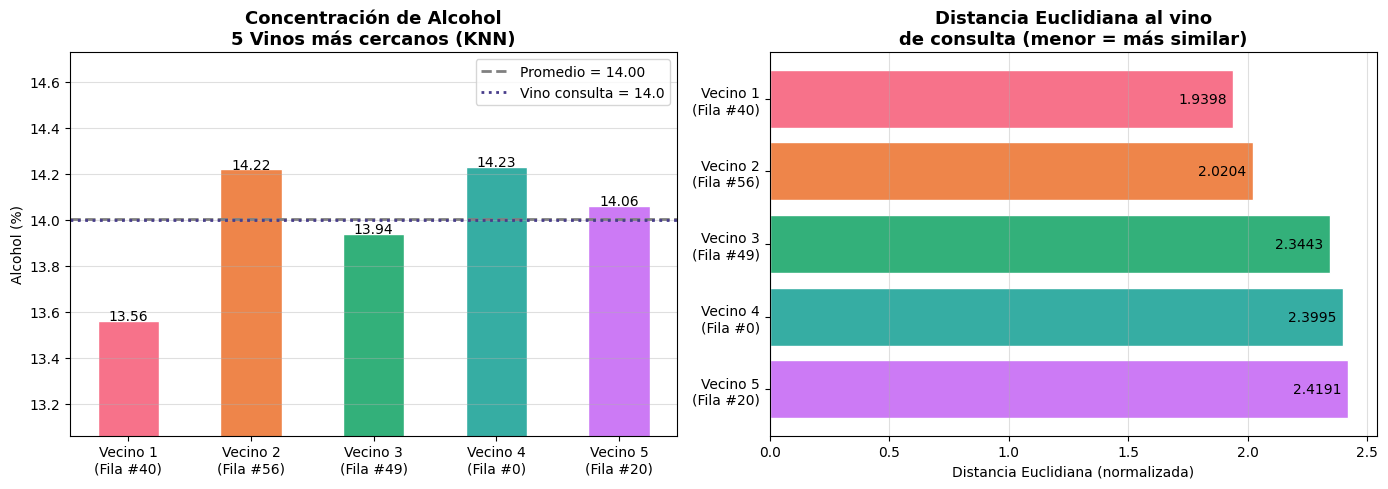

In [41]:
# --- 10. Visualización de resultados ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Alcohol de cada vecino ---
colores = ['#f7728a', '#ee854a', '#33b07a', '#36ada3', '#cc7af5',]
vecino_labels = [f"Vecino {i+1}\n(Fila #{idx})" for i, idx in enumerate(indices[0])]

bars = axes[0].bar(vecino_labels, alcohol_valores, color=colores, edgecolor='white', width=0.5)
axes[0].axhline(y=promedio_alcohol, color='gray', linestyle='--', linewidth=2,
                label=f'Promedio = {promedio_alcohol:.2f}')
axes[0].axhline(y=14, color='darkslateblue', linestyle=':', linewidth=2,
                label='Vino consulta = 14.0')

for bar, val in zip(bars, alcohol_valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.01,
                 f'{val:.2f}', ha='center', va='bottom')

axes[0].set_title('Concentración de Alcohol\n5 Vinos más cercanos (KNN)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Alcohol (%)')
axes[0].set_ylim(min(alcohol_valores) - 0.5, max(alcohol_valores) + 0.5)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# --- Gráfico 2: Distancias euclidianas ---
axes[1].barh(vecino_labels[::-1], distancias[0][::-1], color=colores[::-1], edgecolor='white')
axes[1].set_title('Distancia Euclidiana al vino\nde consulta (menor = más similar)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Distancia Euclidiana (normalizada)')
axes[1].grid(axis='x', alpha=0.4)

for i, (val, label) in enumerate(zip(distancias[0][::-1], vecino_labels[::-1])):
    axes[1].text(val - 0.23, i, f'{val:.4f}', va='center')

plt.tight_layout()
plt.savefig('knn_vino_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

In [99]:
# ============================================================
# CONCLUSIONES PROBLEMA 1: KNN WINE DATASET
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════════╗
║         CONCLUSIONES DEL PROBLEMA 1: KNN WINE DATASET            ║
╚══════════════════════════════════════════════════════════════════╝

VINO DE CONSULTA:
  Alcohol = 14.0 | Malic_Acid=2 | Ash=2.5 | Ash_Alcanity=16 | Magnesium=115  | Total_Phenols=3 | 
  Flavanoids=2.5 | Color_Intensity=9 | Hue=1 | OD280=3.5 | Proline=800

LOS 5 VINOS MÁS CERCANOS (k=5, métrica: distancia euclidiana normalizada):
┌─────────┬──────────┬──────────┬─────────────────────────┐
│ Vecino  │  Fila    │ Alcohol  │ Distancia Euclidiana    │
├─────────┼──────────┼──────────┼─────────────────────────┤
│   1     │   #40    │  13.56   │ 1.9398  ← más cercano   │
│   2     │   #56    │  14.22   │ 2.0204                  │
│   3     │   #49    │  13.94   │ 2.3443                  │
│   4     │    #0    │  14.23   │ 2.3995                  │
│   5     │   #20    │  14.06   │ 2.4191  ← más lejano    │
└─────────┴──────────┴──────────┴─────────────────────────┘

PROMEDIO DE ALCOHOL: (13.56 + 14.22 + 13.94 + 14.23 + 14.06) / 5 = 14.002%

INTERPRETACIÓN:
  1. El promedio de alcohol de los 5 vinos más similares (14.002%) es prácticamente idéntico al alcohol 
     del vino de consulta (14.0%), lo que indica que el modelo KNN encontró vinos muy coherentes
     con las características proporcionadas.

  2. La variación de alcohol entre los vecinos es reducida (rango: 13.56 – 14.23), lo que sugiere que 
     los vinos de este grupo comparten un perfil químico similar y homogéneo.

  3. El vecino más cercano (Fila #40, distancia 1.9398) es el vino más parecido al de consulta en el espacio 
     multidimensional normalizado, con Alcohol = 13.56%.

  4. A pesar de que Color_Intensity=9 y Proline=800 del vino de consulta son valores atípicos para el dataset, 
     el modelo logró identificar 5 vecinos con características consistentes, validando la robustez de la normalización Z aplicada.
""")


╔══════════════════════════════════════════════════════════════════╗
║         CONCLUSIONES DEL PROBLEMA 1: KNN WINE DATASET            ║
╚══════════════════════════════════════════════════════════════════╝

VINO DE CONSULTA:
  Alcohol = 14.0 | Malic_Acid=2 | Ash=2.5 | Ash_Alcanity=16 | Magnesium=115  | Total_Phenols=3 | 
  Flavanoids=2.5 | Color_Intensity=9 | Hue=1 | OD280=3.5 | Proline=800

LOS 5 VINOS MÁS CERCANOS (k=5, métrica: distancia euclidiana normalizada):
┌─────────┬──────────┬──────────┬─────────────────────────┐
│ Vecino  │  Fila    │ Alcohol  │ Distancia Euclidiana    │
├─────────┼──────────┼──────────┼─────────────────────────┤
│   1     │   #40    │  13.56   │ 1.9398  ← más cercano   │
│   2     │   #56    │  14.22   │ 2.0204                  │
│   3     │   #49    │  13.94   │ 2.3443                  │
│   4     │    #0    │  14.23   │ 2.3995                  │
│   5     │   #20    │  14.06   │ 2.4191  ← más lejano    │
└─────────┴──────────┴──────────┴───────────────

# PROBLEMA 2: Market Basket Analysis

In [100]:
# ============================================================
# PROBLEMA 2: MARKET BASKET ANALYSIS
# ============================================================

# --- 1. Importación de librerías ---
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# --- 2. Definición de la lista de compras ---

my_basket = [
    ['bread', 'butter', 'wine', 'bananas', 'coffee', 'carrots'],
    ['tomatoes', 'onions', 'cheese', 'milk', 'potatoes'],
    ['beer', 'chips', 'asparagus', 'salsa', 'milk', 'apples'],
    ['olive oil', 'bread', 'butter', 'tomatoes', 'steak', 'carrots'],
    ['tomatoes', 'onions', 'chips', 'wine', 'ketchup', 'orange juice'],
    ['bread', 'butter', 'beer', 'chips', 'milk'],
    ['butter', 'tomatoes', 'carrots', 'coffee', 'sugar'],
    ['tomatoes', 'onions', 'cheese', 'milk', 'potatoes'],
    ['bread', 'butter', 'ketchup', 'coffee', 'chicken wings'],
    ['butter', 'beer', 'chips', 'asparagus', 'apples'],
    ['tomatoes', 'onion', 'beer', 'chips', 'milk', 'coffee']
]

print("=" * 60)
print(f"Total de tickets de compra: {len(my_basket)}")
print("=" * 60)
for i, ticket in enumerate(my_basket):
    print(f"  Ticket {i+1:>2d}: {ticket}")

Total de tickets de compra: 11
  Ticket  1: ['bread', 'butter', 'wine', 'bananas', 'coffee', 'carrots']
  Ticket  2: ['tomatoes', 'onions', 'cheese', 'milk', 'potatoes']
  Ticket  3: ['beer', 'chips', 'asparagus', 'salsa', 'milk', 'apples']
  Ticket  4: ['olive oil', 'bread', 'butter', 'tomatoes', 'steak', 'carrots']
  Ticket  5: ['tomatoes', 'onions', 'chips', 'wine', 'ketchup', 'orange juice']
  Ticket  6: ['bread', 'butter', 'beer', 'chips', 'milk']
  Ticket  7: ['butter', 'tomatoes', 'carrots', 'coffee', 'sugar']
  Ticket  8: ['tomatoes', 'onions', 'cheese', 'milk', 'potatoes']
  Ticket  9: ['bread', 'butter', 'ketchup', 'coffee', 'chicken wings']
  Ticket 10: ['butter', 'beer', 'chips', 'asparagus', 'apples']
  Ticket 11: ['tomatoes', 'onion', 'beer', 'chips', 'milk', 'coffee']


In [101]:
# --- 3. Codificación con TransactionEncoder ---
# Convierte la lista de listas en una matriz binaria (0/1) donde cada columna = producto y cada fila = ticket de compra

te = TransactionEncoder()
te_array = te.fit(my_basket).transform(my_basket)
basket_df = pd.DataFrame(te_array, columns=te.columns_).astype(int)

print("\nMatriz de presencia/ausencia de productos por ticket:")
basket_df


Matriz de presencia/ausencia de productos por ticket:


,apples,asparagus,bananas,beer,bread,butter,carrots,cheese,chicken wings,chips,...,olive oil,onion,onions,orange juice,potatoes,salsa,steak,sugar,tomatoes,wine
0,0,0,1,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0
2,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,1,1,0,0,0,...,1,0,0,0,0,0,1,0,1,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,1,1
5,0,0,0,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
7,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0
8,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,1,1,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [102]:
# --- 4. Análisis de frecuencia individual ---
print("=" * 60)
print("FRECUENCIA DE CADA PRODUCTO EN LAS COMPRAS")
print("=" * 60)

frecuencias = basket_df.sum().sort_values(ascending=False)
frecuencias_pct = (frecuencias / len(my_basket) * 100).round(1)

freq_df = pd.DataFrame({
    'Producto': frecuencias.index,
    'Apariciones': frecuencias.values,
    'Frecuencia (%)': frecuencias_pct.values
})
print(freq_df.to_string(index=False))

FRECUENCIA DE CADA PRODUCTO EN LAS COMPRAS
     Producto  Apariciones  Frecuencia (%)
     tomatoes            6            54.5
       butter            6            54.5
         milk            5            45.5
        chips            5            45.5
         beer            4            36.4
        bread            4            36.4
       coffee            4            36.4
      carrots            3            27.3
       onions            3            27.3
       apples            2            18.2
     potatoes            2            18.2
      ketchup            2            18.2
    asparagus            2            18.2
       cheese            2            18.2
         wine            2            18.2
    olive oil            1             9.1
        onion            1             9.1
chicken wings            1             9.1
 orange juice            1             9.1
        salsa            1             9.1
        steak            1             9.1
        sug

In [103]:
# --- 5. Algoritmo Apriori ---
# Con datasets pequeños se usa un soporte mínimo bajo
# 11 tickets → soporte de ~18% equivale a aparecer en al menos 2 tickets

# Ajustar min_support según el tamaño del dataset
n_tickets = len(my_basket)
min_sup = 2 / n_tickets  # Al menos 2 tickets (adaptable)

print(f"\nSoporte mínimo utilizado: {min_sup:.4f} ({min_sup*100:.1f}%)")
print(f"  → Un itemset debe aparecer en al menos 2 de {n_tickets} tickets\n")

articulos_frecuentes = apriori(
    basket_df,
    min_support=min_sup,
    use_colnames=True
).sort_values('support', ascending=False).reset_index(drop=True)

articulos_frecuentes['length'] = articulos_frecuentes['itemsets'].apply(lambda x: len(x))
articulos_frecuentes['support_pct'] = (articulos_frecuentes['support'] * 100).round(1)

print("ITEMSETS FRECUENTES:")
print(articulos_frecuentes[['itemsets', 'length', 'support', 'support_pct']].to_string())


Soporte mínimo utilizado: 0.1818 (18.2%)
  → Un itemset debe aparecer en al menos 2 de 11 tickets

ITEMSETS FRECUENTES:
                                      itemsets  length   support  support_pct
0                                     (butter)       1  0.545455         54.5
1                                   (tomatoes)       1  0.545455         54.5
2                                      (chips)       1  0.454545         45.5
3                                       (milk)       1  0.454545         45.5
4                                (beer, chips)       2  0.363636         36.4
5                                       (beer)       1  0.363636         36.4
6                                      (bread)       1  0.363636         36.4
7                                     (coffee)       1  0.363636         36.4
8                              (bread, butter)       2  0.363636         36.4
9                                (milk, chips)       2  0.272727         27.3
10                   

In [104]:
# --- 6. Reglas de asociación por CONFIANZA ---
print("=" * 60)
print("REGLAS DE ASOCIACIÓN (ordenadas por CONFIANZA):")
print("=" * 60)

reglas_conf = association_rules(
    articulos_frecuentes,
    metric='confidence',
    min_threshold=0.5
).sort_values('confidence', ascending=False).reset_index(drop=True)

# Formatear para mejor visualización
reglas_conf['antecedents_str'] = reglas_conf['antecedents'].apply(lambda x: ', '.join(list(x)))
reglas_conf['consequents_str'] = reglas_conf['consequents'].apply(lambda x: ', '.join(list(x)))

cols_mostrar = ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
print(reglas_conf[cols_mostrar].rename(columns={
    'antecedents_str': 'SI COMPRA...',
    'consequents_str': 'TAMBIÉN COMPRA...',
    'support': 'Soporte',
    'confidence': 'Confianza',
    'lift': 'Lift'
}).to_string(index=True))

REGLAS DE ASOCIACIÓN (ordenadas por CONFIANZA):
                           SI COMPRA...                 TAMBIÉN COMPRA...   Soporte  Confianza      Lift
0                                  beer                             chips  0.363636   1.000000  2.200000
1                       asparagus, beer                     chips, apples  0.181818   1.000000  5.500000
2                    potatoes, tomatoes                            cheese  0.181818   1.000000  5.500000
3                                cheese                potatoes, tomatoes  0.181818   1.000000  5.500000
4                              potatoes                  cheese, tomatoes  0.181818   1.000000  5.500000
5                cheese, milk, potatoes                          tomatoes  0.181818   1.000000  1.833333
6                cheese, milk, tomatoes                          potatoes  0.181818   1.000000  5.500000
7            cheese, potatoes, tomatoes                              milk  0.181818   1.000000  2.200000
8      

In [105]:
# --- 7. Reglas de asociación por LIFT ---
print("\n" + "=" * 60)
print("REGLAS DE ASOCIACIÓN (ordenadas por LIFT):")
print("=" * 60)

reglas_lift = association_rules(
    articulos_frecuentes,
    metric='lift',
    min_threshold=1.0
).sort_values('lift', ascending=False).reset_index(drop=True)

reglas_lift['antecedents_str'] = reglas_lift['antecedents'].apply(lambda x: ', '.join(list(x)))
reglas_lift['consequents_str'] = reglas_lift['consequents'].apply(lambda x: ', '.join(list(x)))

print(reglas_lift[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].rename(columns={
    'antecedents_str': 'SI COMPRA...',
    'consequents_str': 'TAMBIÉN COMPRA...',
    'support': 'Soporte',
    'confidence': 'Confianza',
    'lift': 'Lift'
}).to_string(index=True))


REGLAS DE ASOCIACIÓN (ordenadas por LIFT):
                           SI COMPRA...                   TAMBIÉN COMPRA...   Soporte  Confianza      Lift
0                              potatoes                              cheese  0.181818   1.000000  5.500000
1                             asparagus                              apples  0.181818   1.000000  5.500000
2                    potatoes, tomatoes                      cheese, onions  0.181818   1.000000  5.500000
3                                cheese          onions, potatoes, tomatoes  0.181818   1.000000  5.500000
4                              potatoes            cheese, onions, tomatoes  0.181818   1.000000  5.500000
5                        cheese, onions                            potatoes  0.181818   1.000000  5.500000
6                      onions, potatoes                              cheese  0.181818   1.000000  5.500000
7                                cheese                    onions, potatoes  0.181818   1.000000  5.

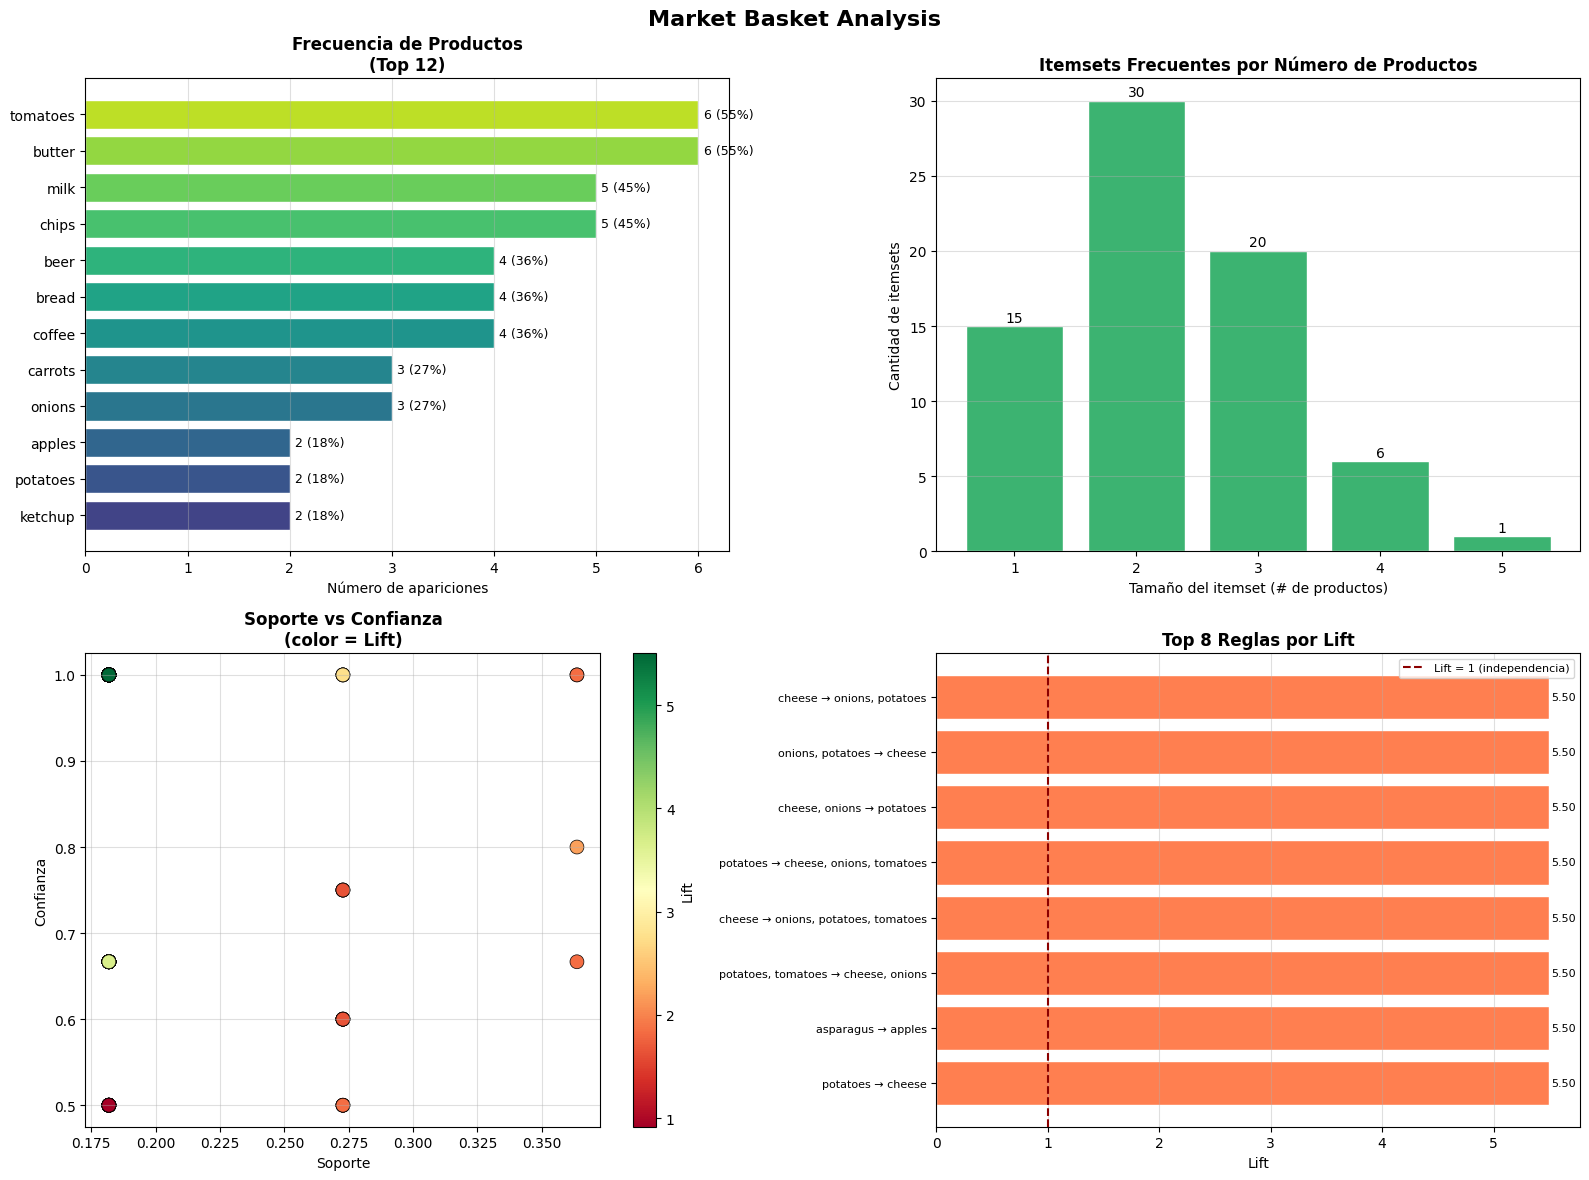

In [107]:
# --- 8. Visualizaciones ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Market Basket Analysis', fontsize=16, fontweight='bold')

# --- Gráfico 1: Frecuencia de productos ---
top_productos = frecuencias.head(12)
colores_bar = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_productos)))
axes[0, 0].barh(top_productos.index[::-1], top_productos.values[::-1], color=colores_bar, edgecolor='white')
axes[0, 0].set_title('Frecuencia de Productos\n(Top 12)', fontweight='bold')
axes[0, 0].set_xlabel('Número de apariciones')
for i, v in enumerate(top_productos.values[::-1]):
    axes[0, 0].text(v + 0.05, i, f'{v} ({v/n_tickets*100:.0f}%)', va='center', fontsize=9)
axes[0, 0].grid(axis='x', alpha=0.4)

# --- Gráfico 2: Itemsets frecuentes por tamaño ---
size_counts = articulos_frecuentes['length'].value_counts().sort_index()
axes[0, 1].bar(size_counts.index, size_counts.values, color=['mediumseagreen'][:len(size_counts)], edgecolor='white')
axes[0, 1].set_title('Itemsets Frecuentes por Número de Productos', fontweight='bold')
axes[0, 1].set_xlabel('Tamaño del itemset (# de productos)')
axes[0, 1].set_ylabel('Cantidad de itemsets')
for i, (x, y) in enumerate(zip(size_counts.index, size_counts.values)):
    axes[0, 1].text(x, y + 0.3, str(y), ha='center')
axes[0, 1].grid(axis='y', alpha=0.4)

# --- Gráfico 3: Scatter Soporte vs Confianza ---
if len(reglas_conf) > 0:
    scatter = axes[1, 0].scatter(
        reglas_conf['support'],
        reglas_conf['confidence'],
        c=reglas_conf['lift'],
        cmap='RdYlGn',
        s=100, edgecolors='black', linewidth=0.5
    )
    plt.colorbar(scatter, ax=axes[1, 0], label='Lift')
    axes[1, 0].set_xlabel('Soporte')
    axes[1, 0].set_ylabel('Confianza')
    axes[1, 0].set_title('Soporte vs Confianza\n(color = Lift)', fontweight='bold')
    axes[1, 0].grid(alpha=0.4)
else:
    axes[1, 0].text(0.5, 0.5, 'Sin reglas\ncon confianza ≥ 0.5', ha='center', va='center', fontsize=12)
    axes[1, 0].set_title('Soporte vs Confianza', fontweight='bold')

# --- Gráfico 4: Top reglas por Lift ---
if len(reglas_lift) > 0:
    top_n = min(8, len(reglas_lift))
    top_reglas = reglas_lift.head(top_n)
    etiquetas = [f"{r['antecedents_str']} → {r['consequents_str']}" for _, r in top_reglas.iterrows()]
    # Acortar etiquetas largas
    etiquetas = [e[:40] + '...' if len(e) > 40 else e for e in etiquetas]

    bars = axes[1, 1].barh(range(top_n), top_reglas['lift'].values, color='coral', edgecolor='white')
    axes[1, 1].set_yticks(range(top_n))
    axes[1, 1].set_yticklabels(etiquetas[::-1] if False else etiquetas, fontsize=8)
    axes[1, 1].set_xlabel('Lift')
    axes[1, 1].set_title(f'Top {top_n} Reglas por Lift', fontweight='bold')
    axes[1, 1].axvline(x=1, color='darkred', linestyle='--', label='Lift = 1 (independencia)')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(axis='x', alpha=0.4)
    for bar, val in zip(bars, top_reglas['lift'].values):
        axes[1, 1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                         f'{val:.2f}', va='center', fontsize=8)
else:
    axes[1, 1].text(0.5, 0.5, 'Sin reglas\ncon lift ≥ 1.0', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.savefig('market_basket_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

In [109]:
# ============================================================
# CONCLUSIONES MARKET BASKET
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════════╗
║       CONCLUSIONES DEL PROBLEMA 2: MARKET BASKET ANALYSIS        ║
╚══════════════════════════════════════════════════════════════════╝

1. PRODUCTOS MÁS FRECUENTES:
   ─────────────────────────────────────────────────────────────
   - Tomatoes y Butter están empatados como los productos más frecuentes: ambos aparecen en 6 de 11 tickets (54.5%).
   - Milk y Chips ocupan el segundo lugar, ambos en 5/11 (45.5%).
   - Beer, Bread y Coffee se encuentran en 4/11 (36.4%).
   - Carrots y Onions aparecen en 3/11 (27.3%).

2. CLUSTERS DE COMPRA DETECTADOS (itemsets frecuentes):
   ─────────────────────────────────────────────────────────────
   Se identificaron dos clústeres principales muy bien definidos:

   CLÚSTER A — "Cocinero de casa": {tomatoes, onions, cheese, milk, potatoes}
     → Aparece de forma idéntica en los Tickets 2 y 8 (18.2%)
     → Genera el mayor número de reglas con Lift = 5.5 y Confianza = 1.0, siendo el patrón más fuerte del análisis.
     → El itemset completo de 5 elementos aparece como el único de tamaño 5 en los itemsets frecuentes.

   CLÚSTER B — "Botana y bebida": {beer, chips, asparagus, apples}
     → Presente en Tickets 3 y 10 con alta co-ocurrencia (18.2%)
     → También genera reglas con Lift = 5.5 y Confianza = 1.0 (ej: asparagus → apples, beer → chips+apples, etc.)
     
   CLÚSTER C — "Despensa básica": {bread, butter, carrots/coffee}
     → Soporte 36.4%, Confianza 1.0, Lift 1.833
     → Patrón recurrente de menor intensidad pero mayor frecuencia.

3. REGLAS CON MAYOR CONFIANZA (Confianza = 1.0):
   ─────────────────────────────────────────────────────────────
   Existen 167 reglas con confianza perfecta (1.0). Las más destacadas por su soporte (más frecuentes) son:

   ★ beer → chips       | Soporte: 36.4%, Lift: 2.20
   ★ bread → butter     | Soporte: 36.4%, Lift: 1.83
   ★ milk, beer → chips | Soporte: 27.3%, Lift: 2.20
   ★ onions → tomatoes  | Soporte: 27.3%, Lift: 1.83
   ★ carrots → butter   | Soporte: 27.3%, Lift: 1.83

   Las reglas del Clúster A (cheese/potatoes/onions/tomatoes/milk) también tienen confianza = 1.0 pero con soporte de 18.2%.

4. REGLAS CON MAYOR LIFT:
   ─────────────────────────────────────────────────────────────
   - El Lift máximo es de 5.50, alcanzado por múltiples reglas de los Clústeres A y B.
   - Lift = 5.5 significa que los productos de esas reglas se compran juntos 5.5 veces más de lo esperado por azar.
   
   TOP REGLAS POR LIFT (Lift = 5.5, Confianza = 1.0):
     • potatoes → cheese
     • asparagus → apples  (y viceversa: apples → asparagus)
     • cheese → onions, potatoes
     • potatoes → cheese, onions, tomatoes
     • beer, apples → asparagus, chips
     • (y más de 100 permutaciones del Clúster A)

5. REGLAS CON LIFT < 1 (relaciones NEGATIVAS detectadas):
   ─────────────────────────────────────────────────────────────
   Se detectaron algunas relaciones con Lift ligeramente < 1:
     • beer, chips → butter | Lift: 0.917
     • beer → butter        | Lift: 0.917
     • coffee → tomatoes    | Lift: 0.917
   Esto indica que quienes compran beer+chips tienden menos a comprar butter de lo que se esperaría por azar 
   (perfiles de compra distintos).

6. RECOMENDACIONES COMERCIALES:
   ─────────────────────────────────────────────────────────────

   a) SEÑALIZACIÓN / CROSS-SELLING con mayor impacto (Lift 5.5):
      → Colocar cheese y potatoes en la misma sección que onions, tomatoes y milk (Clúster A, Lift 5.5).
      → Colocar asparagus junto a apples, beer y chips (Clúster B, Lift 5.5).

   b) BUNDLES / PROMOCIONES de alta frecuencia (Soporte 36.4%):
      → Paquete "picnic": beer + chips (1 de cada 3 clientes)
      → Paquete "desayuno": bread + butter (1 de cada 3 clientes)

   c) SEPARAR los perfiles:
      → El perfil "botana" (beer, chips) y el perfil "cocinero" (tomatoes, onions, potatoes) son mutuamente excluyentes 
        en la mayoría de los tickets; las estrategias de promoción deben apuntar a segmentos distintos.
""")


╔══════════════════════════════════════════════════════════════════╗
║       CONCLUSIONES DEL PROBLEMA 2: MARKET BASKET ANALYSIS        ║
╚══════════════════════════════════════════════════════════════════╝

1. PRODUCTOS MÁS FRECUENTES:
   ─────────────────────────────────────────────────────────────
   - Tomatoes y Butter están empatados como los productos más frecuentes: ambos aparecen en 6 de 11 tickets (54.5%).
   - Milk y Chips ocupan el segundo lugar, ambos en 5/11 (45.5%).
   - Beer, Bread y Coffee se encuentran en 4/11 (36.4%).
   - Carrots y Onions aparecen en 3/11 (27.3%).

2. CLUSTERS DE COMPRA DETECTADOS (itemsets frecuentes):
   ─────────────────────────────────────────────────────────────
   Se identificaron dos clústeres principales muy bien definidos:

   CLÚSTER A — "Cocinero de casa": {tomatoes, onions, cheese, milk, potatoes}
     → Aparece de forma idéntica en los Tickets 2 y 8 (18.2%)
     → Genera el mayor número de reglas con Lift = 5.5 y Confianza = 1.0, siendo